# Advanced Linear Models

**Flow:** Bayesian linear models that report uncertainty and prune features (BayesianRidge, ARD) → scalable fitting with stochastic gradient descent (SGDRegressor) → path/greedy sparse methods (LARS, LassoLars, OMP) → jointly sparse multi-output models (MultiTaskLasso, MultiTaskElasticNet).

These estimators extend the linear toolkit for specific needs: quantified coefficient uncertainty, large-scale streaming data, efficient sparse solution paths, and shared structure across multiple correlated targets. Every example uses deterministic synthetic data, a train/test split before fitting, and a held-out score.


## 1. Setup and versions

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Colorblind-safe Okabe-Ito categorical palette used throughout this curriculum.
OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import (BayesianRidge, ARDRegression, SGDRegressor,
    Lars, LassoLars, OrthogonalMatchingPursuit, lars_path,
    MultiTaskLasso, MultiTaskElasticNet, LinearRegression)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(21)


## 2. Bayesian linear models: coefficients with uncertainty
**BayesianRidge** places priors on the coefficients and noise and returns a posterior, so predictions come with a standard deviation. **ARDRegression** (Automatic Relevance Determination) uses a per-coefficient prior that drives irrelevant coefficients toward zero — automatic sparsity. We build data with only a few truly relevant features among many noise features.

In [3]:
n, p, k = 200, 12, 3           # 12 features, only first 3 relevant
Xr = rng.normal(size=(n, p))
true_coef = np.zeros(p)
true_coef[:k] = [4.0, -3.0, 2.0]
y = Xr @ true_coef + rng.normal(0, 1.0, size=n)
Xtr, Xte, ytr, yte = train_test_split(Xr, y, test_size=0.3, random_state=0)

bayes = make_pipeline(StandardScaler(), BayesianRidge()).fit(Xtr, ytr)
ard = make_pipeline(StandardScaler(), ARDRegression()).fit(Xtr, ytr)
mean_p, std_p = bayes[-1].predict(bayes[:-1].transform(Xte), return_std=True)
print(f'BayesianRidge test R^2: {r2_score(yte, bayes.predict(Xte)):.3f}')
print(f'ARDRegression test R^2: {r2_score(yte, ard.predict(Xte)):.3f}')
print(f'Mean predictive std on test set: {std_p.mean():.3f}')


BayesianRidge test R^2: 0.964
ARDRegression test R^2: 0.966
Mean predictive std on test set: 1.199


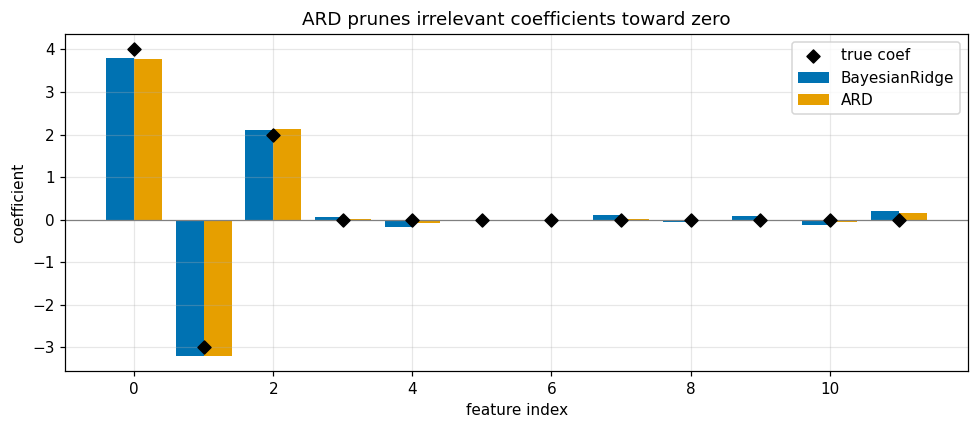

In [4]:
idx = np.arange(p)
width = 0.4
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(idx - width/2, bayes[-1].coef_, width, color=OKABE_ITO[0], label='BayesianRidge')
ax.bar(idx + width/2, ard[-1].coef_, width, color=OKABE_ITO[1], label='ARD')
ax.scatter(idx, true_coef, color=OKABE_ITO[7], zorder=5, marker='D', label='true coef')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('feature index'); ax.set_ylabel('coefficient')
ax.set_title('ARD prunes irrelevant coefficients toward zero')
ax.legend(); plt.tight_layout(); plt.show()


## 3. SGDRegressor: linear models that scale
`SGDRegressor` fits the same linear objective by **stochastic gradient descent**, updating on small batches. This scales to data too large for closed-form solvers and supports different penalties. It is sensitive to feature scaling and learning-rate settings, so we standardize inside a pipeline and select the penalty strength with cross-validation.

In [5]:
param_grid = {'sgdregressor__alpha': np.logspace(-5, -1, 9)}
sgd_pipe = make_pipeline(StandardScaler(),
                         SGDRegressor(penalty='l2', max_iter=5000, tol=1e-4, random_state=0))
cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(sgd_pipe, param_grid, cv=cv, scoring='r2').fit(Xtr, ytr)
print(f'Best alpha by CV: {search.best_params_["sgdregressor__alpha"]:.1e}')
print(f'Best mean CV R^2: {search.best_score_:.3f}')
print(f'Held-out test R^2 (SGD): {r2_score(yte, search.predict(Xte)):.3f}')
ols = LinearRegression().fit(Xtr, ytr)
print(f'Held-out test R^2 (OLS closed-form baseline): {r2_score(yte, ols.predict(Xte)):.3f}')


Best alpha by CV: 1.0e-02
Best mean CV R^2: 0.948
Held-out test R^2 (SGD): 0.964
Held-out test R^2 (OLS closed-form baseline): 0.964


## 4. LARS, LassoLars, and OMP: sparse solution paths
**Least Angle Regression (LARS)** builds the solution by adding features in order of correlation with the residual, producing the whole regularization **path** cheaply. **LassoLars** solves the Lasso along that path. **Orthogonal Matching Pursuit (OMP)** greedily selects a fixed number of nonzero coefficients. We visualize the LARS coefficient path and compare held-out error.

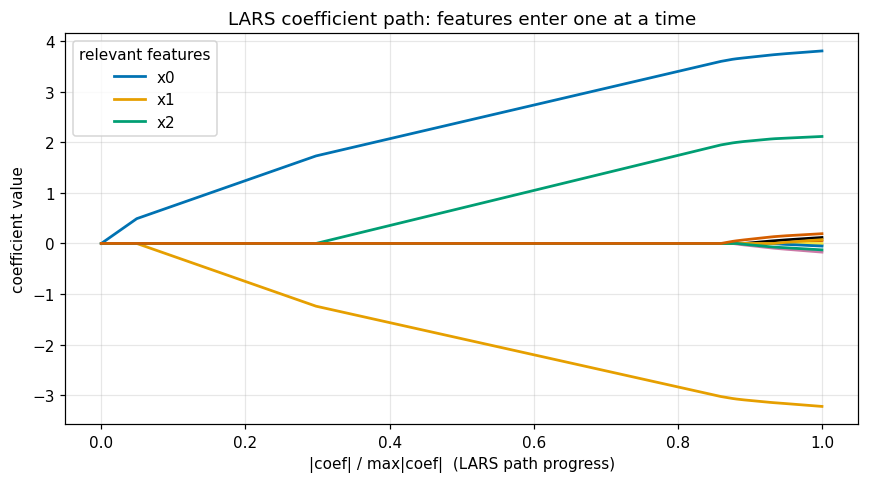

In [6]:
Xs = StandardScaler().fit_transform(Xtr)
alphas, _, coefs = lars_path(Xs, ytr - ytr.mean(), method='lasso')
xx = np.sum(np.abs(coefs.T), axis=1)
xx /= xx[-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
for j in range(coefs.shape[0]):
    ax.plot(xx, coefs[j], color=OKABE_ITO[j % len(OKABE_ITO)], lw=1.8,
            label=f'x{j}' if j < k else None)
ax.set_xlabel('|coef| / max|coef|  (LARS path progress)')
ax.set_ylabel('coefficient value')
ax.set_title('LARS coefficient path: features enter one at a time')
ax.legend(title='relevant features', loc='best'); plt.tight_layout(); plt.show()


In [7]:
lars = make_pipeline(StandardScaler(), Lars(n_nonzero_coefs=6)).fit(Xtr, ytr)
lasso_lars = make_pipeline(StandardScaler(), LassoLars(alpha=0.01)).fit(Xtr, ytr)
omp = make_pipeline(StandardScaler(), OrthogonalMatchingPursuit(n_nonzero_coefs=k)).fit(Xtr, ytr)
for name, mdl in [('LARS', lars), ('LassoLars', lasso_lars), ('OMP', omp)]:
    nnz = int(np.sum(np.abs(mdl[-1].coef_) > 1e-8))
    print(f'{name:12s} test R^2={r2_score(yte, mdl.predict(Xte)):.3f}  nonzero coefs={nnz}')


LARS         test R^2=0.964  nonzero coefs=6
LassoLars    test R^2=0.965  nonzero coefs=11
OMP          test R^2=0.966  nonzero coefs=3


## 5. Multi-task models: shared sparsity across outputs
When predicting **several correlated targets** that plausibly depend on the *same* subset of features, `MultiTaskLasso` and `MultiTaskElasticNet` enforce a shared sparsity pattern: a feature is either used by all tasks or none. This is stronger than fitting independent Lassos. We generate 3 targets sharing the same active features.

MultiTaskLasso         mean test R^2 across 3 tasks: 0.836
MultiTaskElasticNet    mean test R^2 across 3 tasks: 0.828


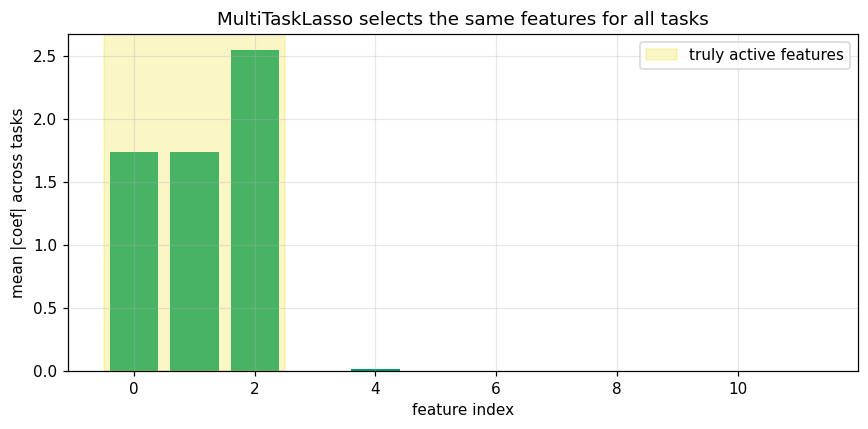

In [8]:
T = 3
shared = np.zeros((p, T))
shared[:k] = rng.normal(size=(k, T)) * 3      # same active rows across all tasks
Ymt = Xr @ shared + rng.normal(0, 1.0, size=(n, T))
Xmt_tr, Xmt_te, Ymt_tr, Ymt_te = train_test_split(Xr, Ymt, test_size=0.3, random_state=6)

mtl = make_pipeline(StandardScaler(), MultiTaskLasso(alpha=0.2, max_iter=5000)).fit(Xmt_tr, Ymt_tr)
mten = make_pipeline(StandardScaler(),
                     MultiTaskElasticNet(alpha=0.2, l1_ratio=0.5, max_iter=5000)).fit(Xmt_tr, Ymt_tr)
for name, mdl in [('MultiTaskLasso', mtl), ('MultiTaskElasticNet', mten)]:
    pred = mdl.predict(Xmt_te)
    print(f'{name:22s} mean test R^2 across {T} tasks: '
          f'{r2_score(Ymt_te, pred, multioutput="uniform_average"):.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
coef_mag = np.abs(mtl[-1].coef_).mean(axis=0)   # avg |coef| per feature across tasks
ax.bar(np.arange(p), coef_mag, color=OKABE_ITO[2])
ax.axvspan(-0.5, k - 0.5, color=OKABE_ITO[6], alpha=0.3, label='truly active features')
ax.set_xlabel('feature index'); ax.set_ylabel('mean |coef| across tasks')
ax.set_title('MultiTaskLasso selects the same features for all tasks')
ax.legend(); plt.tight_layout(); plt.show()


## Key takeaways and caveats

- **BayesianRidge / ARD** yield predictions with uncertainty; ARD additionally prunes irrelevant features via per-coefficient priors. Priors are assumptions — inspect them and validate.
- **SGDRegressor** scales to very large or streaming data but is sensitive to scaling and learning-rate/penalty hyperparameters. Standardize inside a pipeline and tune with CV. For small data, closed-form OLS/Ridge is simpler and often better.
- **LARS / LassoLars** give the full regularization path efficiently; **OMP** targets an explicit sparsity level. As with any sparse method, selected features are a modeling property, not proof of importance — correlated features make selection unstable.
- **Multi-task models** share a sparsity pattern across correlated outputs, which helps when the assumption of shared support is true and hurts when it is not.
- Every model here was split before fitting, tuned with CV where a hyperparameter existed, and scored once on held-out data.
